In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

data = load_iris(as_frame=True)
iris = data.frame.copy()
iris['species'] = iris['target'].map({0:'setosa',1:'versicolor',2:'virginica'})
iris = iris.drop(columns=['target'])

print("First 5 rows:")
print(iris.head())


First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [2]:
# Q1: Which species has the largest average petal length?
print("\n--- Q1 ---")
print(iris.groupby('species')['petal length (cm)'].mean())



--- Q1 ---
species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal length (cm), dtype: float64



--- Q2 ---
Overall correlation (sepal vs petal length): 0.8717537758865831
By species:
setosa 0.26717575886875716
versicolor 0.754048958592016
virginica 0.8642247329355764


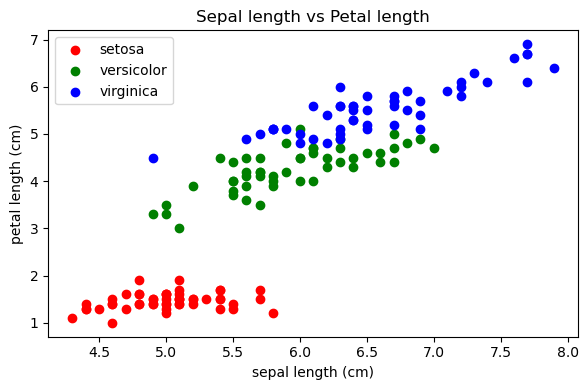

In [4]:
# Q2: Do sepal length and petal length appear correlated? If yes, is it stronger for some species than others?
print("\n--- Q2 ---")
print("Overall correlation (sepal vs petal length):",
      iris['sepal length (cm)'].corr(iris['petal length (cm)']))
print("By species:")
for sp in iris['species'].unique():
    sub = iris[iris['species'] == sp]
    print(sp, sub['sepal length (cm)'].corr(sub['petal length (cm)']))

colors = {'setosa':'red', 'versicolor':'green', 'virginica':'blue'}
plt.figure(figsize=(6,4))
for sp, color in colors.items():
    sub = iris[iris['species'] == sp]
    plt.scatter(sub['sepal length (cm)'], sub['petal length (cm)'],
                label=sp, color=color)
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title('Sepal length vs Petal length')
plt.legend()
plt.tight_layout()
plt.show()


--- Q3 ---

Feature: sepal length (cm)
species
setosa        5.006
versicolor    5.936
virginica     6.588
Name: sepal length (cm), dtype: float64

Feature: sepal width (cm)
species
setosa        3.428
versicolor    2.770
virginica     2.974
Name: sepal width (cm), dtype: float64

Feature: petal length (cm)
species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal length (cm), dtype: float64

Feature: petal width (cm)
species
setosa        0.246
versicolor    1.326
virginica     2.026
Name: petal width (cm), dtype: float64


<Figure size 600x400 with 0 Axes>

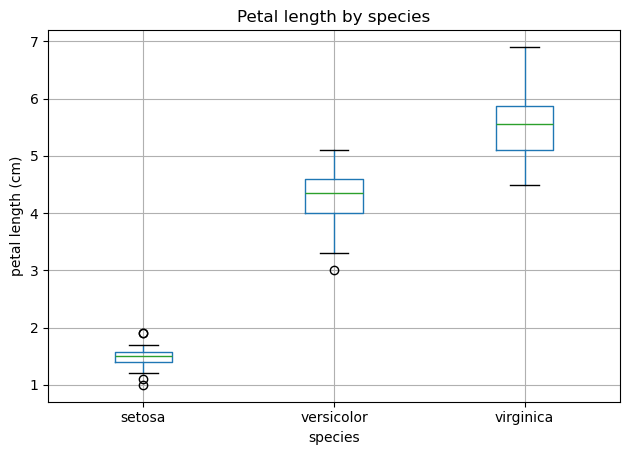

In [5]:
# Q3: Which feature has the least overlap between species (best for classification)?
print("\n--- Q3 ---")
for col in ['sepal length (cm)', 'sepal width (cm)',
            'petal length (cm)', 'petal width (cm)']:
    print("\nFeature:", col)
    print(iris.groupby('species')[col].mean())

plt.figure(figsize=(6,4))
iris.boxplot(column='petal length (cm)', by='species')
plt.title('Petal length by species')
plt.suptitle("")
plt.xlabel('species')
plt.ylabel('petal length (cm)')
plt.tight_layout()
plt.show()

In [6]:
# Q4: Are there any outliers in petal width? If so, which species do they belong to?
print("\n--- Q4 ---")
for sp in iris['species'].unique():
    vals = iris[iris['species']==sp]['petal width (cm)']
    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    outliers = vals[(vals < lower) | (vals > upper)]
    print(sp, "outliers count:", len(outliers))


--- Q4 ---
setosa outliers count: 2
versicolor outliers count: 0
virginica outliers count: 0


In [ ]:
# Q5: short answer
print("\n--- Q5 ---")
print("Petal length (and petal width) clearly separate species best.")

# Q6: sepal length vs petal width
print("\n--- Q6 ---")
print("Correlation (sepal length vs petal width):", 
      iris['sepal length (cm)'].corr(iris['petal width (cm)']))
median = iris['sepal length (cm)'].median()
short_mean = iris[iris['sepal length (cm)'] < median]['petal width (cm)'].mean()
long_mean  = iris[iris['sepal length (cm)'] >= median]['petal width (cm)'].mean()
print("Mean petal width (short sepals):", round(short_mean,3))
print("Mean petal width (long sepals):", round(long_mean,3))
